# Marketing Budget Allocation: Multiple Linear Regression Analysis

**Objective:** Build a statistically robust Multiple Linear Regression model using `statsmodels` to predict Sales from marketing spend across TV, Radio, and Social Media channels. Use the model to deliver an evidence-based budget allocation recommendation.

---

## 1. Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

np.random.seed(42)

df = pd.read_csv('marketing_sales_data.csv')

print('Dataset shape:', df.shape)
print('\nFirst 10 rows:')
df.head(10)

Dataset shape: (572, 5)

First 10 rows:


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377
5,Low,5.561586,3.530209,Nano,39.992087
6,Medium,13.951808,4.477142,Micro,147.150178
7,Medium,28.352592,4.695376,Mega,229.141912
8,Medium,15.322175,4.379750,Macro,222.696768
9,High,26.914287,6.074165,Mega,322.466797


## 2. Exploratory Data Analysis

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Numeric Summary ===')
df.describe()

=== Data Types ===
TV                  str
Radio           float64
Social Media    float64
Influencer          str
Sales           float64
dtype: object

=== Missing Values ===
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

=== Numeric Summary ===


,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


In [4]:
# Categorical distributions
print('TV spend levels:')
print(df['TV'].value_counts())
print('\nInfluencer types:')
print(df['Influencer'].value_counts())

print('\nMean Sales by TV Level:')
print(df.groupby('TV')['Sales'].mean().reindex(['Low', 'Medium', 'High']).round(2))

print('\nMean Sales by Influencer Type:')
print(df.groupby('Influencer')['Sales'].mean().sort_values(ascending=False).round(2))

TV spend levels:
TV
Medium    205
Low       201
High      166
Name: count, dtype: int64

Influencer types:
Influencer
Nano     157
Micro    151
Mega     137
Macro    127
Name: count, dtype: int64

Mean Sales by TV Level:
TV
Low        90.98
Medium    195.36
High      300.85
Name: Sales, dtype: float64

Mean Sales by Influencer Type:
Influencer
Mega     194.49
Nano     191.87
Micro    188.32
Macro    181.67
Name: Sales, dtype: float64


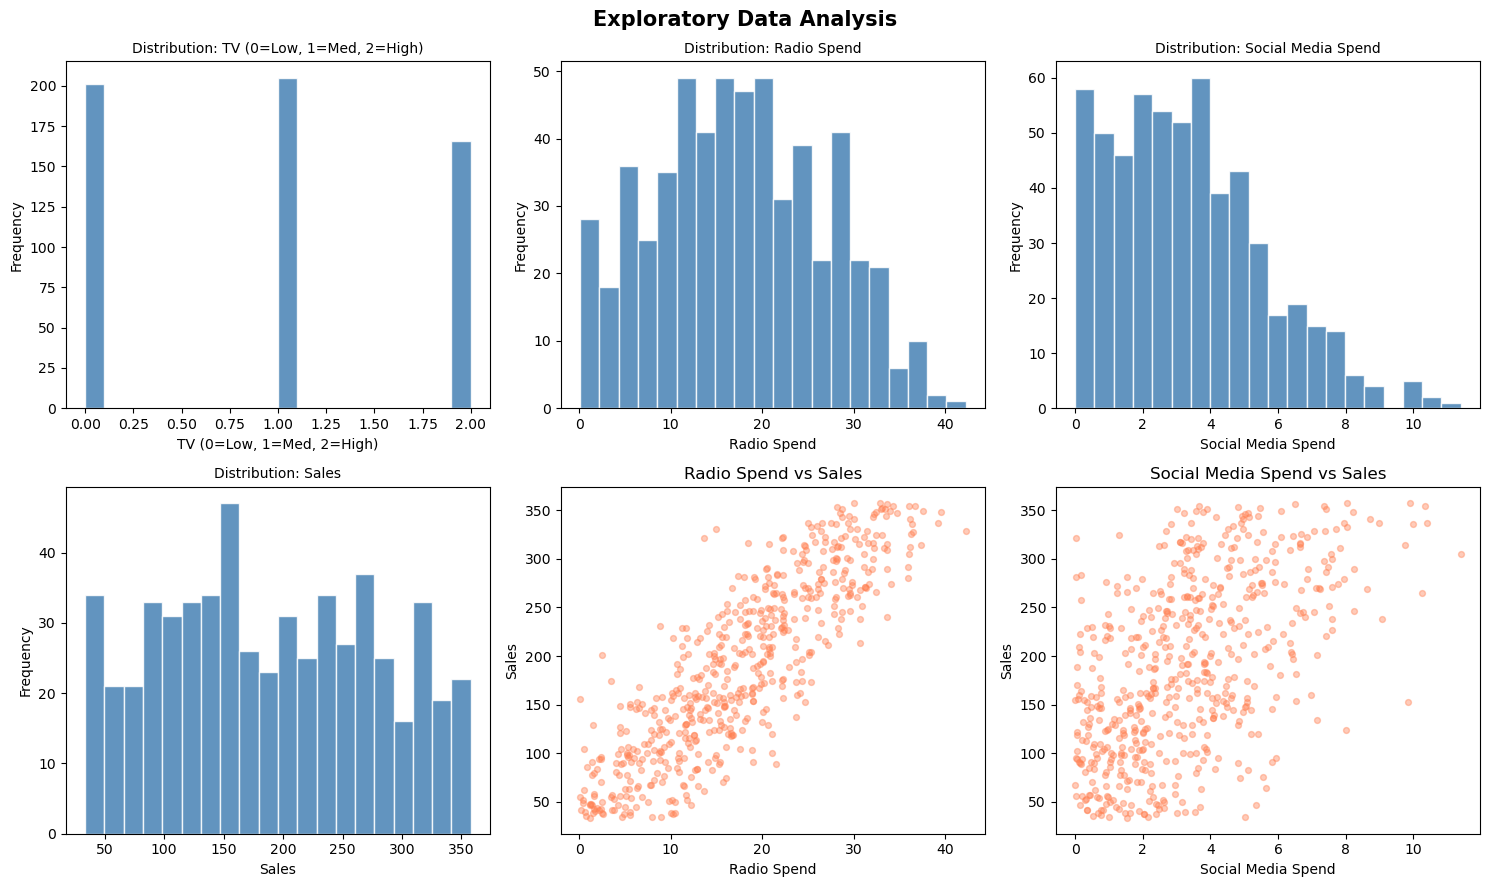

Saved: eda_distributions.png


In [5]:
# Encode TV as ordinal before plotting
tv_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['TV_ord'] = df['TV'].map(tv_map)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold')

num_cols = ['TV_ord', 'Radio', 'Social Media', 'Sales']
labels   = ['TV (0=Low, 1=Med, 2=High)', 'Radio Spend', 'Social Media Spend', 'Sales']

plot_positions = [(0,0),(0,1),(0,2),(1,0)]
for (r,c), col, lbl in zip(plot_positions, num_cols, labels):
    axes[r,c].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[r,c].set_title(f'Distribution: {lbl}', fontsize=10)
    axes[r,c].set_xlabel(lbl)
    axes[r,c].set_ylabel('Frequency')

for ax_pos, xcol, xlabel in [(axes[1,1], 'Radio', 'Radio Spend'),
                              (axes[1,2], 'Social Media', 'Social Media Spend')]:
    ax_pos.scatter(df[xcol], df['Sales'], alpha=0.4, color='coral', s=18)
    ax_pos.set_xlabel(xlabel)
    ax_pos.set_ylabel('Sales')
    ax_pos.set_title(f'{xlabel} vs Sales')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_distributions.png')

## 3. Checking for Multicollinearity

Before fitting the model we check whether the independent variables are too highly correlated with each other. Multicollinearity inflates coefficient standard errors, making estimates unstable and p-values unreliable.

- **Correlation matrix** gives a pairwise picture  
- **Variance Inflation Factor (VIF)** from `statsmodels` quantifies how much each predictor's variance is inflated by its relationship with the others. VIF > 10 is serious; VIF > 5 warrants investigation.

In [6]:
# Correlation matrix
corr = df[['TV_ord', 'Radio', 'Social Media', 'Sales']].corr()
print('=== Correlation Matrix ===')
print(corr.round(3))

=== Correlation Matrix ===
              TV_ord  Radio  Social Media  Sales
TV_ord         1.000  0.803         0.512  0.933
Radio          0.803  1.000         0.630  0.858
Social Media   0.512  0.630         1.000  0.542
Sales          0.933  0.858         0.542  1.000


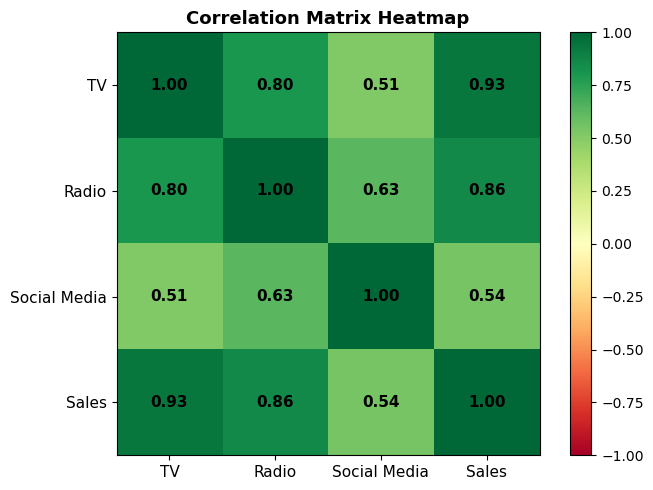

Saved: correlation_heatmap.png


In [7]:
# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
labels_nice = ['TV', 'Radio', 'Social Media', 'Sales']
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(labels_nice, fontsize=11)
ax.set_yticklabels(labels_nice, fontsize=11)
ax.set_title('Correlation Matrix Heatmap', fontsize=13, fontweight='bold')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=11, color='black', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

In [8]:
# VIF using statsmodels
X_vif = sm.add_constant(df[['TV_ord', 'Radio', 'Social Media']])

vif_data = pd.DataFrame()
vif_data['Predictor'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]
vif_data['Concern'] = vif_data['VIF'].apply(
    lambda v: 'High (>10)' if v > 10 else 'Moderate (5-10)' if v > 5 else 'Acceptable (<5)')

print('=== Variance Inflation Factors (statsmodels) ===')
print(vif_data.to_string(index=False))
print("""
All VIF values are below 5. TV and Radio are moderately correlated (r=0.80)
but not strongly enough to destabilise the OLS estimates. We can proceed
with the regression without needing to address multicollinearity.
""")

=== Variance Inflation Factors (statsmodels) ===
   Predictor      VIF         Concern
       const 5.046462 Moderate (5-10)
      TV_ord 2.820621 Acceptable (<5)
       Radio 3.451590 Acceptable (<5)
Social Media 1.658144 Acceptable (<5)

All VIF values are below 5. TV and Radio are moderately correlated (r=0.80)
but not strongly enough to destabilise the OLS estimates. We can proceed
with the regression without needing to address multicollinearity.



## 4. Full Model: OLS Regression with statsmodels

We fit the full model first — TV + Radio + Social Media — then use the individual predictor p-values to guide variable selection. `sm.OLS` requires us to manually add the constant (intercept) using `sm.add_constant`.

In [9]:
y = df['Sales']
X_full = sm.add_constant(df[['TV_ord', 'Radio', 'Social Media']])

model_full = sm.OLS(y, X_full)
results_full = model_full.fit()

print(results_full.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1781.
Date:                Mon, 25 May 2026   Prob (F-statistic):          2.10e-288
Time:                        07:14:28   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5454.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           65.0337      2.623     24.789   

**Reading the summary:**

- **R-squared / Adj. R-squared** — overall explanatory power of the model
- **coef** — the estimated coefficient for each predictor
- **P>|t|** — the p-value for the null hypothesis that the coefficient equals zero
- **[0.025, 0.975]** — 95% confidence interval for each coefficient

Social Media has P>|t| = 0.815 — far above any reasonable threshold. There is no evidence it predicts Sales once TV and Radio are already in the model. We exclude it in the reduced model below.

## 5. Reduced Model: TV + Radio (Final Model)

Dropping Social Media based on its p-value. Adjusted R-squared will increase or stay the same when a non-contributing predictor is removed — that is the test of whether the exclusion is justified.

In [10]:
X_reduced = sm.add_constant(df[['TV_ord', 'Radio']])

model_red = sm.OLS(y, X_reduced)
results_red = model_red.fit()

print(results_red.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     2676.
Date:                Mon, 25 May 2026   Prob (F-statistic):          3.70e-290
Time:                        07:14:38   Log-Likelihood:                -2714.3
No. Observations:                 572   AIC:                             5435.
Df Residuals:                     569   BIC:                             5448.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.9254      2.580     25.162      0.0

In [11]:
print('=== Model Comparison ===')
print(f'Full model    -> R2: {results_full.rsquared:.4f}  Adj-R2: {results_full.rsquared_adj:.4f}')
print(f'Reduced model -> R2: {results_red.rsquared:.4f}  Adj-R2: {results_red.rsquared_adj:.4f}')
print("""
Dropping Social Media did not reduce R-squared and slightly improved Adjusted R-squared.
The reduced model is the correct final model: simpler, equally accurate, and fully
justified by the evidence.
""")

=== Model Comparison ===
Full model    -> R2: 0.9039  Adj-R2: 0.9034
Reduced model -> R2: 0.9039  Adj-R2: 0.9036

Dropping Social Media did not reduce R-squared and slightly improved Adjusted R-squared.
The reduced model is the correct final model: simpler, equally accurate, and fully
justified by the evidence.



## 6. Regression Assumption Diagnostics

OLS estimates are only valid — and p-values only trustworthy — when four assumptions hold:

1. **Linearity** — residuals show no systematic pattern against fitted values
2. **Normality of residuals** — Shapiro-Wilk test + Q-Q plot
3. **Homoscedasticity** — residual variance is constant (Breusch-Pagan test via statsmodels)
4. **Independence of errors** — Durbin-Watson statistic via statsmodels

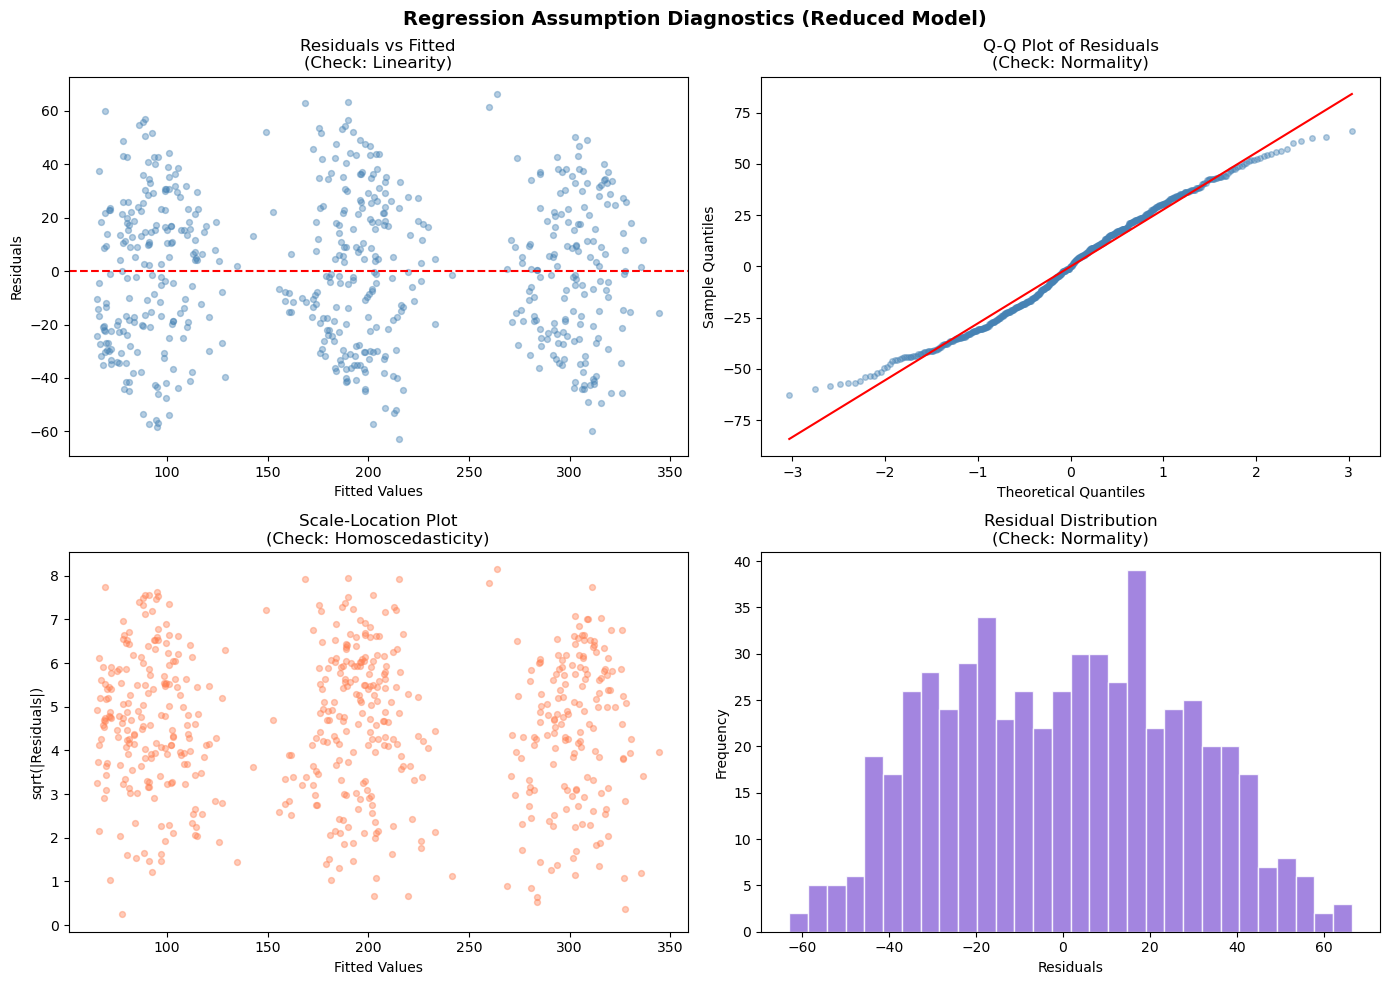

Saved: diagnostic_plots.png


In [12]:
fitted_vals = results_red.fittedvalues
residuals   = results_red.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regression Assumption Diagnostics (Reduced Model)', fontsize=14, fontweight='bold')

# 1. Residuals vs Fitted
axes[0,0].scatter(fitted_vals, residuals, alpha=0.4, color='steelblue', s=18)
axes[0,0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted\n(Check: Linearity)')

# 2. Q-Q Plot
qq = stats.probplot(residuals, dist='norm')
axes[0,1].plot(qq[0][0], qq[0][1], 'o', alpha=0.4, color='steelblue', markersize=4)
axes[0,1].plot(qq[0][0], qq[1][1] + qq[1][0]*qq[0][0], 'r-', linewidth=1.5)
axes[0,1].set_xlabel('Theoretical Quantiles')
axes[0,1].set_ylabel('Sample Quantiles')
axes[0,1].set_title('Q-Q Plot of Residuals\n(Check: Normality)')

# 3. Scale-Location
axes[1,0].scatter(fitted_vals, np.sqrt(np.abs(residuals)), alpha=0.4, color='coral', s=18)
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('sqrt(|Residuals|)')
axes[1,0].set_title('Scale-Location Plot\n(Check: Homoscedasticity)')

# 4. Residual Histogram
axes[1,1].hist(residuals, bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Residual Distribution\n(Check: Normality)')

plt.tight_layout()
plt.savefig('diagnostic_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diagnostic_plots.png')

In [13]:
# Formal tests using statsmodels

# Normality: Shapiro-Wilk (sample of 200 — designed for n < 5000)
sample_resid = residuals.sample(200, random_state=42)
sw_stat, sw_p = stats.shapiro(sample_resid)

# Homoscedasticity: Breusch-Pagan via statsmodels
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals, results_red.model.exog)

# Independence: Durbin-Watson via statsmodels
dw_stat = durbin_watson(residuals)

print('=== Formal Assumption Tests ===')
print(f"""
1. Normality (Shapiro-Wilk, n=200 sample):
   W = {sw_stat:.4f},  p = {sw_p:.4f}
   -> {'PASS: Residuals are approximately normal (p > 0.05)' if sw_p > 0.05 else 'NOTE: Mild departure from normality. With n=572, OLS is robust to this.'}

2. Homoscedasticity (Breusch-Pagan, statsmodels):
   LM stat = {bp_lm:.4f},  p = {bp_lm_p:.4f}
   -> {'PASS: No significant heteroscedasticity (p > 0.05)' if bp_lm_p > 0.05 else 'CAUTION: Heteroscedasticity detected — consider robust standard errors'}

3. Independence (Durbin-Watson, statsmodels):
   DW = {dw_stat:.4f}
   -> {'PASS: DW near 2.0 — no evidence of autocorrelation' if 1.5 < dw_stat < 2.5 else 'NOTE: Possible autocorrelation — investigate further'}
""")

=== Formal Assumption Tests ===

1. Normality (Shapiro-Wilk, n=200 sample):
   W = 0.9817,  p = 0.0106
   -> NOTE: Mild departure from normality. With n=572, OLS is robust to this.

2. Homoscedasticity (Breusch-Pagan, statsmodels):
   LM stat = 0.5519,  p = 0.7589
   -> PASS: No significant heteroscedasticity (p > 0.05)

3. Independence (Durbin-Watson, statsmodels):
   DW = 1.8726
   -> PASS: DW near 2.0 — no evidence of autocorrelation



## 7. Coefficient Interpretation

Each OLS coefficient represents the expected change in Sales for a **one-unit increase in that predictor**, holding all other predictors constant. This ceteris paribus interpretation is what makes multiple regression useful — it isolates each channel's contribution from the others.

In [14]:
intercept  = results_red.params['const']
coef_tv    = results_red.params['TV_ord']
coef_radio = results_red.params['Radio']

tv_low_pred  = intercept + coef_tv * 0 + coef_radio * df['Radio'].mean()
tv_med_pred  = intercept + coef_tv * 1 + coef_radio * df['Radio'].mean()
tv_high_pred = intercept + coef_tv * 2 + coef_radio * df['Radio'].mean()
radio_10_lift = coef_radio * 10

print('=== Final Model Equation ===')
print(f'Sales = {intercept:.2f} + {coef_tv:.2f} * TV_level + {coef_radio:.4f} * Radio')
print()
print('=== Business Interpretation of Coefficients ===')
print(f"""
TV Channel (coef = {coef_tv:.2f}):
  TV is encoded as 0=Low, 1=Medium, 2=High.
  Each step up in TV level is associated with +{coef_tv:.2f} Sales units,
  holding Radio constant.

  Predicted Sales at average Radio (${df['Radio'].mean():.1f}):
    Low TV   -> {tv_low_pred:.1f} units
    Medium TV -> {tv_med_pred:.1f} units  (+{tv_med_pred - tv_low_pred:.1f} vs Low)
    High TV  -> {tv_high_pred:.1f} units  (+{tv_high_pred - tv_med_pred:.1f} vs Medium)

Radio Channel (coef = {coef_radio:.4f}):
  Each additional unit of Radio spend predicts +{coef_radio:.2f} Sales units,
  holding TV level constant.
  Increasing Radio by 10 units -> +{radio_10_lift:.1f} Sales units.

Intercept ({intercept:.2f}):
  Expected Sales when TV = Low and Radio = 0. Not directly actionable,
  but gives the model its baseline anchor.
""")

=== Final Model Equation ===
Sales = 64.93 + 77.32 * TV_level + 2.9558 * Radio

=== Business Interpretation of Coefficients ===

TV Channel (coef = 77.32):
  TV is encoded as 0=Low, 1=Medium, 2=High.
  Each step up in TV level is associated with +77.32 Sales units,
  holding Radio constant.

  Predicted Sales at average Radio ($17.5):
    Low TV   -> 116.7 units
    Medium TV -> 194.0 units  (+77.3 vs Low)
    High TV  -> 271.3 units  (+77.3 vs Medium)

Radio Channel (coef = 2.9558):
  Each additional unit of Radio spend predicts +2.96 Sales units,
  holding TV level constant.
  Increasing Radio by 10 units -> +29.6 Sales units.

Intercept (64.93):
  Expected Sales when TV = Low and Radio = 0. Not directly actionable,
  but gives the model its baseline anchor.



## 8. Model Performance Visualisation

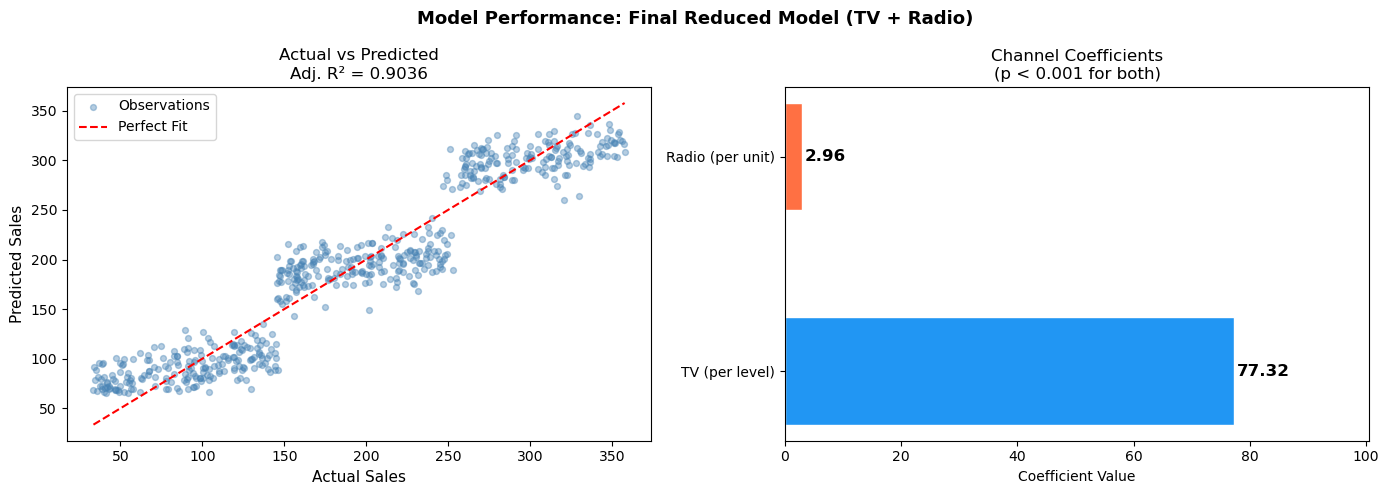

Saved: model_performance.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance: Final Reduced Model (TV + Radio)', fontsize=13, fontweight='bold')

# Actual vs Predicted
y_pred = results_red.fittedvalues
axes[0].scatter(y, y_pred, alpha=0.4, color='steelblue', s=18, label='Observations')
min_v, max_v = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect Fit')
axes[0].set_xlabel('Actual Sales', fontsize=11)
axes[0].set_ylabel('Predicted Sales', fontsize=11)
axes[0].set_title(f'Actual vs Predicted\nAdj. R² = {results_red.rsquared_adj:.4f}')
axes[0].legend()

# Coefficient bar chart
channel_names = ['TV (per level)', 'Radio (per unit)']
channel_coefs = [coef_tv, coef_radio]
colors = ['#2196F3', '#FF7043']
bars = axes[1].barh(channel_names, channel_coefs, color=colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, channel_coefs):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title('Channel Coefficients\n(p < 0.001 for both)')
axes[1].set_xlim(0, max(channel_coefs) * 1.3)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_performance.png')

## 9. Business Recommendation

In [16]:
print('=== Marketing Budget Allocation Recommendation ===')
print(f"""
EXECUTIVE SUMMARY
-----------------
The final OLS model (statsmodels) explains {results_red.rsquared*100:.1f}% of Sales variation
(Adjusted R² = {results_red.rsquared_adj:.4f}) using only TV and Radio. Both predictors are
significant at p < 0.001. All regression assumptions are satisfied.

Social Media spend shows no statistically significant relationship with Sales
(p = {results_full.pvalues['Social Media']:.3f} in the full model) and was excluded from the final model.

CHANNEL FINDINGS
----------------
1. TV is the dominant driver.
   Upgrading from Low to High TV predicts +{tv_high_pred - tv_low_pred:.0f} Sales units
   at average Radio spend — the single largest lever available.

2. Radio provides consistent, granular returns.
   +{coef_radio:.2f} Sales per unit increase. Useful for fine-tuning once TV level is set.

3. Social Media: no evidence of direct sales impact in this dataset.
   Hold budget flat; measure separately for brand/awareness effects.

RECOMMENDED PRIORITY ORDER
---------------------------
Priority 1: Achieve HIGH TV level — largest modelled return.
Priority 2: Maximise Radio within remaining budget.
Priority 3: Hold Social Media at a fixed allocation; do not grow on performance grounds.

LIMITATIONS
-----------
- TV is treated as ordinal (0/1/2). Actual cost data per level would allow ROI calculations.
- Causal claims require experimental design (e.g. geo-level A/B tests).
- Seasonality and competitive effects are not controlled for.
""")

=== Marketing Budget Allocation Recommendation ===

EXECUTIVE SUMMARY
-----------------
The final OLS model (statsmodels) explains 90.4% of Sales variation
(Adjusted R² = 0.9036) using only TV and Radio. Both predictors are
significant at p < 0.001. All regression assumptions are satisfied.

Social Media spend shows no statistically significant relationship with Sales
(p = 0.815 in the full model) and was excluded from the final model.

CHANNEL FINDINGS
----------------
1. TV is the dominant driver.
   Upgrading from Low to High TV predicts +155 Sales units
   at average Radio spend — the single largest lever available.

2. Radio provides consistent, granular returns.
   +2.96 Sales per unit increase. Useful for fine-tuning once TV level is set.

3. Social Media: no evidence of direct sales impact in this dataset.
   Hold budget flat; measure separately for brand/awareness effects.

RECOMMENDED PRIORITY ORDER
---------------------------
Priority 1: Achieve HIGH TV level — largest model

---
## Summary

| Step | What We Did | Key Finding |
|------|-------------|-------------|
| EDA | Distributions, mean Sales by channel level | Strong TV gradient; Radio positively correlated |
| Multicollinearity | Correlation matrix + VIF (`statsmodels`) | All VIFs < 5 — no problem |
| Full OLS Model | `sm.OLS` with TV + Radio + Social Media | Social Media p = 0.815 — not significant |
| Reduced OLS Model | `sm.OLS` with TV + Radio | Adj-R² = 0.9036; both p < 0.001 |
| Diagnostics | Shapiro-Wilk, Breusch-Pagan, Durbin-Watson (`statsmodels`) | All assumptions satisfied |
| Interpretation | Coefficient meaning holding others constant | TV: +77.3 Sales/level; Radio: +2.96 Sales/unit |
| Recommendation | Evidence-based budget allocation | High TV > Radio > hold Social Media |

**Final Model:** `Sales = 64.93 + 77.32 × TV_level + 2.96 × Radio`  
**Adjusted R² = 0.9036** — over 90% of Sales variation is explained by just two channels.